https://www.youtube.com/watch?v=92WaNz9mPeY

## 시장 리스크(Market Risk)

시장 리스크는 주가, 금리, 환율, 원자재 등 시장가격이 존재하는 상품에 대해, 시장가격의 변동에 따른 자산가치의 변동 가능성을 의미한다. 즉, 시장에서 거래되는 모든 자산은 시장 리스크에 노출되어 있다고 할 수 있다. 특히 금융권에서 주로 다루는 시장리스크는 주가, 금리, 환율 등과 같은 금융 자산의 시장리스크이다.

금융권에서 시장 리스크에 관심을 갖고 관리하려는 가장 큰 이유는 무엇일까? 시장 리스크의 심화는 결국 보유하고 있는 자산의 변동성 증가, 혹은 예상 손실 증가로 이어져 결국 회사의 자산 손실로 이어질 가능성을 의미한다. 이에 대한 충분한 대비(적절한 자기자본 보유 등)을 하지 않으면 회사의 건전성 악화로 이어져 결국 금융 회사가 마주하는 단기 채무(펀드 환매, 은행 예금 지급, 보험금 지급 등)에 적절하게 대응하지 못하는 유동성 위기가 발생할 가능성이 발생한다. 이를 조기에 막기 위해 시장 리스크를 관리해야만 한다.

## 최대 예상 손실(Value at Risk)

최대 예상 손실은 주어진 시간과 사전 정의된 신뢰구간 동안 회사가 가지고 있는 자산의 최대 예상 손실을 측정하는데 사용되는 시장리스크 관리 지표이다. 예를 들어 투자의 일 VaR이 95% 신뢰구간에서 100만 달러라는 것은 해당 포트폴리오를 소유한 투자자가 하루에 100만 달러 이상의 손해를 입을 가능성이 5%라는 의미이다. 

VaR의 구성 요소에는 신뢰구간, 기간, 포트폴리오 가치, 그리고 변동성으로 이루어져 있다.

다음은 VaR 분석에서 주목해야 할 몇 가지 중요한 사항을 요약한 것이다.

1. VaR은 손실 가능성에 대한 추정이 필요하다.

2. VaR은 잠재적 손실에 대한 예측이다. 실현 손실에 대한 예측이 아니다.

3. VaR은 신뢰구간, 변동성, 기간이라는 3 가지 핵심 요소를 가지고 있다.


VaR의 수학적 정의는 다음과 같다. 

Given some cumulative density function $F$, the generalized inverse $F^{<-}$ is called the quantile function of F. For $\alpha \in (0,1)$, the $\alpha$ - quantile of F is given by,

$$q_{\alpha}(F)= \  F^{<-}(\alpha)=inf\{x \in R : F(x) \geq \alpha \} $$

여기서 이 quantile function을 loss function에 적용한 것이 바로 VaR이 된다. 즉, $F_L(l) = P(L \leq l)$ (단, l은 loss를 의미)로 정의한다면

$$VaR_{\alpha}(L)=inf\{l \in R : P(L>l) \leq 1-\alpha \}=inf\{l \in R : F_L(l) \geq \alpha \} $$

라고 정의된다.


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import yfinance as yf
from scipy.stats import norm
import requests
from io import StringIO
import seaborn as sns
import warnings
import scipy.stats as stats

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (8,4)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150

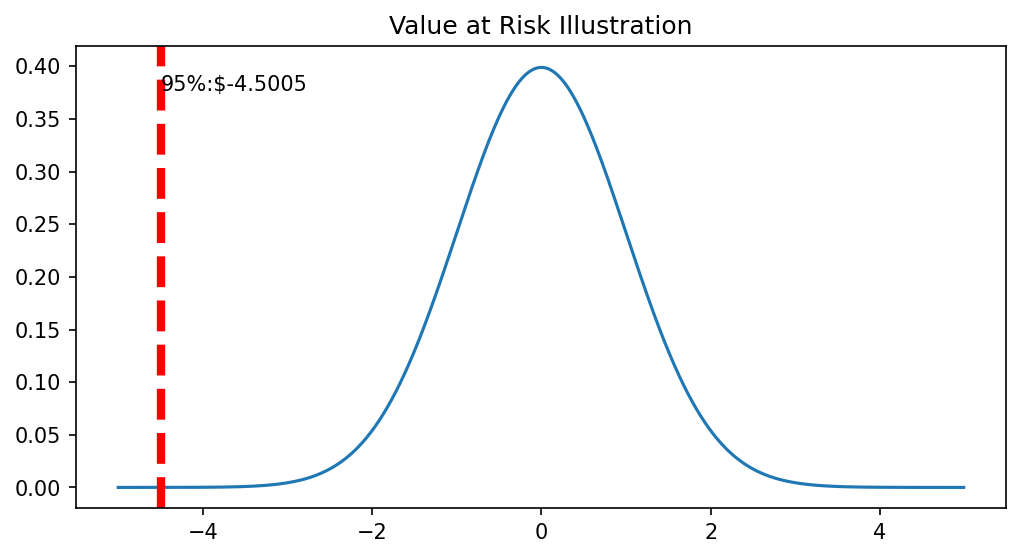

In [52]:
mean = 0
std_dev = 1
x = np.arange(-5, 5, 0.01)
y = norm.pdf(x, mean, std_dev)
pdf = plt.plot(x, y)
min_ylim, max_ylim = plt.ylim()
plt.text(np.percentile(x, 5), max_ylim * 0.9, '95%:${:.4f}'
         .format(np.percentile(x, 5)))
plt.axvline(np.percentile(x, 5), color='r', linestyle='dashed',
            linewidth=4)
plt.title('Value at Risk Illustration')
plt.show()

VaR에는 일반적으로 3가지 접근법이 존재한다. 

1. 분산 - 공분산 VaR
2. 과거 시뮬레이션 VaR
3. 몬테 카를로 VaR

## Variance-Covariance Method

분산 - 공분산 기법은 다른 말로 델타-노말 기법이라고도 한다. 이는 관측값의 분포(ex : 주식 수익률의 분포, 이자율의 분포, 기초자산의 분포 등)가 정규분포를 따른다는 것과 기초자산과 포트폴리오 가치의 관계가 선형임을 가정하고 VaR을 계산하는 것을 의미한다. 따라서 이를 모수적 방법이라고 부르기도 한다.

델타-노말 가정을 바탕으로 모형을 고려해보자. 만약 loss function이 선형이고, risk factor가 정규분포를 따른다면 VaR은

$$VaR_{\alpha}=\mu + \sigma \Phi^{-1}(\alpha)$$

가 된다. (단, $\Phi^{-1}$은 표준정규분포함수의 역함수)

분산 - 공분산 기법에서 가장 중요한 것은 포트폴리오의 공분산 행렬을 구하는 것이다. 일반적으로 과거 데이터를 사용해 공분산 행렬, 평균 벡터 등을 계산한다.

다음은 분산 - 공분산 기법을 사용해 VaR을 계산하는 과정이다.

In [53]:
symbols = ["IBM", "MSFT", "INTC"]
stocks = pd.DataFrame()
for symbol in symbols:
    stocks=pd.concat( [ yf.download(symbol, '2020-01-01', '2020-12-31')['Close'], stocks], axis=1)


stocks.columns = symbols

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [54]:
stocks.head()

,IBM,MSFT,INTC
Date,,,
2020-01-02,53.666470,152.158401,99.446770
2020-01-03,53.013721,150.263763,98.653656
2020-01-06,52.863762,150.652145,98.477402
2020-01-07,51.981670,149.278534,98.543480
2020-01-08,52.016960,151.656311,99.365974


In [55]:
stocks_returns = (np.log(stocks) - np.log(stocks.shift(1))).dropna()
stocks_returns

,IBM,MSFT,INTC
Date,,,
2020-01-03,-0.012238,-0.012530,-0.008007
2020-01-06,-0.002833,0.002581,-0.001788
2020-01-07,-0.016827,-0.009160,0.000671
2020-01-08,0.000679,0.015803,0.008312
2020-01-09,0.005580,0.012416,0.010513
...,...,...,...
2020-12-23,0.008626,-0.013125,0.002343
2020-12-24,0.010679,0.007797,0.006356
2020-12-28,0.000000,0.009873,0.001042


In [56]:
stocks_returns_mean = stocks_returns.mean()
weights  = [1/3]*3
weights /= np.sum(weights)
cov_var = stocks_returns.cov()
port_std = np.sqrt(weights.T.dot(cov_var).dot(weights))
stock_cov=np.diag(cov_var)   # 각 종목 분산 데이터

In [57]:
port_return_mean = np.dot(stocks_returns, weights).mean()

In [ ]:
initial_investment = 1e6   # 원금 100만 달러에 대해 동일비중 포트폴리오와 각 종목에만 투자하는 세가지 포트폴리오 비교
conf_level = 0.95

In [ ]:
def VaR_parametric(initial_investment, conf_level, cov):
    alpha = norm.ppf(1 - conf_level, stocks_returns_mean, port_std) 
    for i, j in zip(stocks.columns, range(len(stocks.columns))):
        VaR_param = -initial_investment * (alpha)[j]
        print("Parametric VaR result for {} is {} ".format(i, VaR_param))
    VaR_param = -initial_investment * (alpha)
    print('--' * 25)
    return VaR_param

In [60]:
VaR_param = VaR_parametric(initial_investment, conf_level, stock_cov)

alpha = norm.ppf(1 - conf_level, port_return_mean, port_std)
VaR_param_port = (initial_investment - initial_investment * (1 + alpha))
print("Parametric VaR result for {} is {} ".format("equal_weight_portfolio", VaR_param_port))

Parametric VaR result for IBM is 43418.86401345522 
Parametric VaR result for MSFT is 41308.456116976035 
Parametric VaR result for INTC is 42770.51960462604 
--------------------------------------------------
Parametric VaR result for equal_weight_portfolio is 42499.279911685735 


데이터가 iid로 산출되었다고 가정할 때, 일간변동성 $\sigma$가 주어졌다면 t기간의 변동성 $\sigma_t$는 $\sigma_t=\sigma \sqrt {t}$로 계산할 수 있다. 즉 VaR은 보유 기간이 길어질 수록 더욱 커지는 성질을 가지고 있다. 다음 그림는 보유기간에 따른 VaR의 변화를 보여준다.

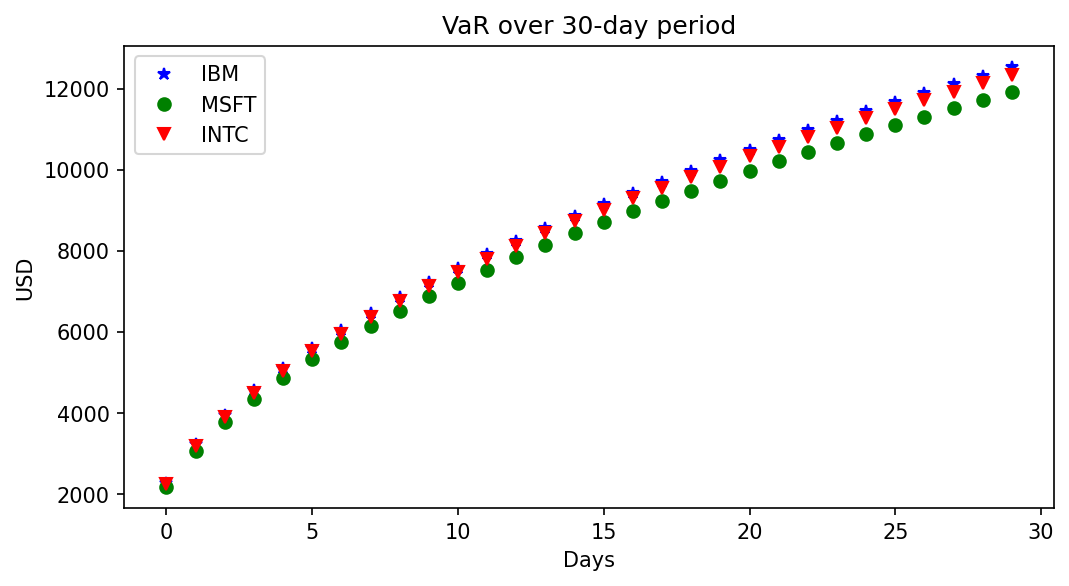

In [61]:
var_horizon = []
time_horizon = 30
for j in range(len(stocks_returns.columns)):
    for i in range(1, time_horizon + 1):
        var_horizon.append(VaR_param[j] * np.sqrt(i/360))
plt.plot(var_horizon[:time_horizon], "o",
         c='blue', marker='*', label='IBM')
plt.plot(var_horizon[time_horizon:time_horizon + 30], "o",
         c='green', marker='o', label='MSFT')
plt.plot(var_horizon[time_horizon + 30:time_horizon + 60], "o",
         c='red', marker='v', label='INTC')
plt.xlabel("Days")
plt.ylabel("USD")
plt.title("VaR over 30-day period")
plt.legend()
plt.show()

하지만 이 time rule은 수익률이 iid를 따른다는 가정이 뒷받침되어야만 성립한다. 만일 이 가정이 성립하지 않는다면, 위의 time rule은 성립하지 않게 된다. 이는 특히 자기상관과 변동성 군집 현상을 모두 보이는 금융 데이터에서 많이 깨지는 가정으로 이 가정을 그대로 사용하면 시장이 위기 국면에 진입했을 때 꼬리 위험을 과소평가할 위험이 존재한다.

분산 - 공분산 기법의 장점은 다음과 같다.

1. 계산이 용이하다.


분산 - 공분산 기법의 단점은 다음과 같다.

1. 일반적으로 금융 데이터는 정규분포를 따르지 않는다. 이는 특히 위기상황에서 부각되는 단점이다.
2. 비선형 구조에서는 오차가 발생한다.
3. 공분산 행렬의 계산이 필요하며, 이는 높은 시간복잡도를 요구한다.

## Historical Simulation VaR

역사적 시뮬레이션 방법은 분포를 가정하지 않는다는 점에서 비모수적 방법이라고도 불린다. 역사적 시뮬레이션은 과거 관측치에서 해당 신뢰구간에 맞는 백분위수를 찾은 뒤, 이 백분위수에 초기 투자를 곱하는 방법으로 VaR을 계산한다.

역사적 시뮬레이션 방법을 정리하면 다음과 같다.

1. 포트폴리오의 과거 수익률 계산
2. 신뢰구간을 기반으로 해당 수익 백분위수 계산
3. 이 백분위수에 초기 투자를 곱해 VaR 계산

다음은 역사적 시뮬레이션 방법을 구현한 코드이다.


In [ ]:
def VaR_historical(initial_investment, conf_level):
    Hist_percentile95 = []
    for i, j in zip(stocks_returns.columns,
                    range(len(stocks_returns.columns))):
        Hist_percentile95.append(np.percentile(stocks_returns.loc[:, i], #이게 핵심 코드! #stocks_returns.loc[:, i]가 우리가 찾고싶은 종목
                                             5)) #의 하위 5퍼센트
        print("Based on historical values 95% of {}'s return is {:.4f}"
             .format(i, Hist_percentile95[j]))
        VaR_historical = (initial_investment - initial_investment *
                         (1 + Hist_percentile95[j]))
        print("Historical VaR result for {} is {:.2f} "
             .format(i, VaR_historical))
        print('--' * 35)

In [63]:
VaR_historical(initial_investment,conf_level)

Based on historical values 95% of IBM's return is -0.0425
Historical VaR result for IBM is 42509.09 
----------------------------------------------------------------------
Based on historical values 95% of MSFT's return is -0.0426
Historical VaR result for MSFT is 42622.23 
----------------------------------------------------------------------
Based on historical values 95% of INTC's return is -0.0372
Historical VaR result for INTC is 37201.07 
----------------------------------------------------------------------


역사적 시뮬레이션은 금융 데이터의 구조적 변화가 없다고 암묵적으로 가정한다는 한계가 존재한다. 즉, 시뮬레이션 결과가 과거 데이터에 과적합될 가능성이 존재한다.

역사적 시뮬레이션의 장점은 다음과 같다.

1. 분포에 대한 가정이 없다.
2. 비선형 구조에서도 잘 작동한다.
3. 계산이 간편하다.


역사적 시뮬레이션의 단점은 다음과 같다.

1. 많은 샘플이 필요하다.
2. 시뮬레이션 결과가 과거 데이터에 과적합될 가능성이 존재한다.

## Monte Carlo VaR

몬테 카를로 VaR 기법에 대해 알아보기 전에, 몬테 카를로 시뮬레이션에 대해 우선 알아보자.


몬테카를로 시뮬레이션이란, 통계학에서 사용되는 큰 수의 법칙을 금융에 이용한 것이다. 파생상품뿐만이 아닌 모든 자산의 가격은 다음 식을 만족한다.

$$ P_t = e^{-r(T-t)}E(CF_T) $$

이때 $P_t$는 자산의 현재 가격, $CF_T$는 만기 시점에서의 현금흐름이다. 또 $t$는 현재 시점을, $T$는 만기 시점을 나타낸다. $r$은 할인률을 의미한다. 즉, 만기 시점에서의 현금흐름의 기댓값을 현재가치화한 것이 자산의 가격이다.
하지만 현금흐름의 기댓값을 수학적으로 구하기 어렵다는 것이 가격결정의 가장 큰 문제점이다. 몬테카를로 시뮬레이션은 이 문제를 큰 수의 법칙을 이용해 해결한다.
큰 수의 법칙은 다음과 같다.

If $N$ is big,
$$ E(X) \approx {{(X_1 + X_2 + X_3 + ...+ X_N)}\over N} $$

몬테카를로 시뮬레이션은 큰 수의 법칙을 이용해 현재 알고 있는 주가의 분포를 활용해 가능한 주가 시나리오를 최대한 많이 제작하여, 만기 시점에서의 현금흐름의 평균을 구해 현재가치화하는 방법을 사용한다.

가장 기본적으로 사용되는 주가 분포 시나리오는 기하브라운 운동(GBM)이다. GBM을 따르는 주가는 다음 확률과정을 따른다.

$$ {dS \over S}  = \mu dt + \sigma dW $$

이때 $\mu$는 해당 주식에 대한 요구수익률, $\sigma$는 주가의 $dt$시간 동안의 변동성, $dW$는 표준정규분포를 따르는 확률변수이다.

즉 이 식에서 시나리오를 제작해야 하는 불확실한 과정, 즉 확률과정은 $dW$ 뿐이므로, $dW$의 시나리오를 제작하여 위 식에 대입하면 주가의 시나리오를 제작할 수 있다.

하지만 포트폴리오 자산 간에는 상관관계가 존재하므로, 상관관계를 가지는 여러 개의 자산을 분석할 때에는 단순히 두 개의 기하브라운 식을 구축하는 것으로는 충분하지 않다. 이를 위해서는 촐레스키 분해를 사용한다.

촐레스키 분해를 통해 상관계수 행렬은 다음과 같이 분해된다.
$$\Omega = \begin{bmatrix} 1 & \rho \\ \rho & 1 \end{bmatrix} = \begin{bmatrix} 1 & 0 \\ \rho &\sqrt{1-\rho^2}  \end{bmatrix}	\begin{bmatrix} 1 & \rho \\ 0 &\sqrt{1-\rho^2}  \end{bmatrix} = LL^T	$$

그리고 $L$을 곱한 난수행렬을 다음과 같이 정의하면 새로운 두 난수는 $\rho$의 상관계수를 가지는 난수가 된다.

$$
\begin{bmatrix} Z_1 \\ Z_2 \end{bmatrix} = L \begin{bmatrix} W_1  \\ W_2 \end{bmatrix} 
$$ 

(단, $W_1, W_2$는 Wiener stochastic process)

이는 자산이 N개일때도 동일하게 적용이 가능하다.

몬테 카를로 시뮬레이션에서는 위의 방법을 사용해 주가의 시나리오를 제작하고, 시나리오를 바탕으로 주어진 신뢰구간에 해당하는 백분위수의 수익률을 찾아 VaR을 계산하는 방법을 사용한다. 역사적 시뮬레이션과 비슷한 과정을 거치나, 데이터가 시뮬레이션 데이터냐 과거 데이터냐에 차이가 존재한다.

다음 코드는 촐레츠키 분해를 사용해 몬테 카를로 시뮬레이션을 수행하고 해당 데이터를 바탕으로 VaR을 계산하는 과정이다. 편의를 위해 요구수익률을 0.01로 고정하였다

In [64]:
import scipy

T = 1
days = 250
nsimulation = 300000
r=0.01
stock_sigma=np.sqrt(stock_cov)  # 각 종목의 일별 변동성

L=scipy.linalg.cholesky(np.corrcoef([stocks_returns.iloc[:, 0], stocks_returns.iloc[:, 1], stocks_returns.iloc[:, 2]]), lower=True)

Normal1 = np.random.normal(size=(T*days, nsimulation))
Normal2 = np.random.normal(size=(T*days, nsimulation))
Normal3 = np.random.normal(size=(T*days, nsimulation))

nor1 = Normal1.reshape(1,T*days*nsimulation)
nor2 = Normal2.reshape(1,T*days*nsimulation)
nor3 = Normal3.reshape(1,T*days*nsimulation)

dz=[]
for i in range(len(nor1)):
    dz.append(np.dot(L, np.array([nor1[i], nor2[i], nor3[i]])))

dz=np.array(dz[0])

cor1 = dz[0, :]
cor2 = dz[1, :]
cor3 = dz[2, :]

Normal1 = cor1.reshape(T*days,nsimulation)
Normal2 = cor2.reshape(T*days,nsimulation)
Normal3 = cor3.reshape(T*days,nsimulation)


dt = 1/250
logds1 = r*dt + Normal1 * stock_sigma[0]
logds2 = r*dt + Normal2 * stock_sigma[1]
logds3 = r*dt + Normal3 * stock_sigma[2]

path1 = np.zeros((T*days+1,nsimulation))
path2 = np.zeros((T*days+1,nsimulation))
path3= np.zeros((T*days+1,nsimulation))

path1[0] = 129.46463
path2[0] = 160.619995
path3[0] = 60.840000

for i in range(1,T*days+1):
    path1[i] = path1[i-1]*(1+logds1[i-1])  # 이미 일별 변동성을 계산했으므로 np.sqrt(dt)를 안곱해줘도 됨!
    path2[i] = path2[i-1]*(1+logds2[i-1])
    path3[i]= path3[i-1]*(1+logds3[i-1])

path1=pd.DataFrame(path1)
IBM_return=(np.log(path1)-np.log(path1.shift(1))).dropna()
path2=pd.DataFrame(path2)
MSFT_return=(np.log(path2)-np.log(path2.shift(1))).dropna()
path3=pd.DataFrame(path3)
INTC_return=(np.log(path3)-np.log(path3.shift(1))).dropna()


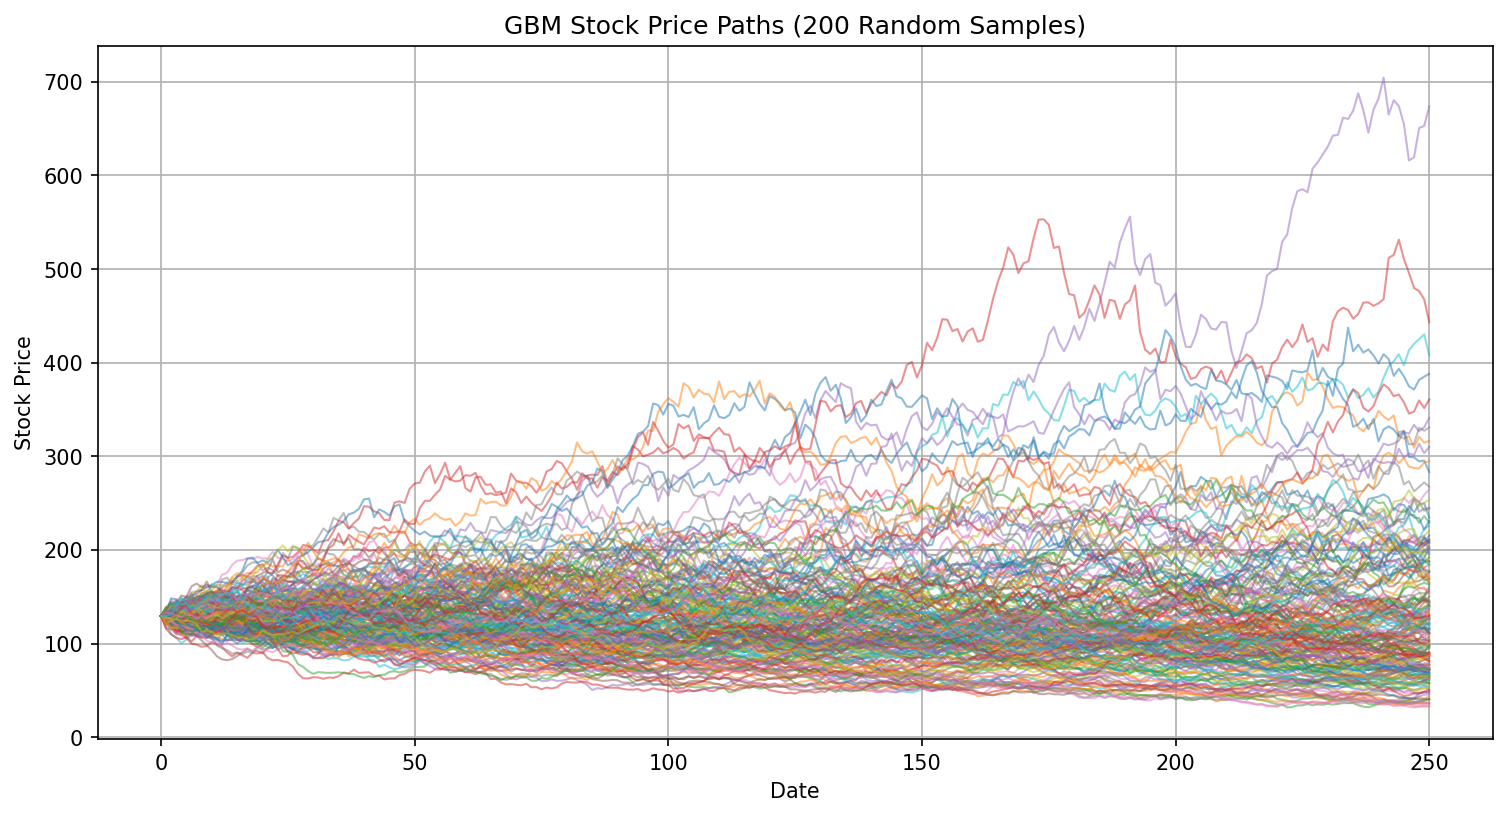

In [65]:
# 2. 시각화를 위해 무작위로 200개만 샘플링
num_samples_to_plot = 200
sampled_indices = np.random.choice(path1.shape[1], num_samples_to_plot, replace=False)
sampled_paths = path1.loc[:, sampled_indices]

# 3. 플롯 그리기
plt.figure(figsize=(12, 6))
plt.plot(sampled_paths, alpha=0.5, linewidth=1) # alpha값을 주어 겹치는 부분을 반투명하게 처리
plt.title(f"GBM Stock Price Paths ({num_samples_to_plot} Random Samples)")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.grid(True)
plt.show()

In [66]:
sim_return=pd.concat( [pd.Series(np.array(IBM_return).flatten()), pd.Series(np.array(MSFT_return).flatten()), pd.Series(np.array(INTC_return).flatten())], axis=1)
sim_return.columns=stocks.columns
sim_return

,IBM,MSFT,INTC
0,0.010193,0.020834,0.022592
1,0.045927,0.025458,-0.005112
2,-0.030062,-0.064893,-0.014676
3,0.025352,-0.007268,-0.008138
4,0.002630,0.023645,0.006241
...,...,...,...
74999995,-0.009239,-0.011507,0.002254
74999996,0.046485,0.022172,-0.000937
74999997,0.024157,0.025485,-0.007873
74999998,0.004234,-0.010509,-0.024297


In [67]:
def MC_VaR(initial_investment, conf_level):
    MC_percentile95 = []
    for i, j in zip(sim_return.columns, range(len(sim_return.columns))):
        MC_percentile95.append(np.percentile(sim_return.loc[:, i], 5))
        print("Based on simulation 95% of {}'s return is {:.4f}"
              .format(i, MC_percentile95[j]))
        VaR_MC = (initial_investment - initial_investment * 
                  (1 + MC_percentile95[j]))
        print("Simulation VaR result for {} is {:.2f} "
              .format(i, VaR_MC))
        print('--' * 35)

In [68]:
MC_VaR(initial_investment, conf_level)

Based on simulation 95% of IBM's return is -0.0576
Simulation VaR result for IBM is 57637.78 
----------------------------------------------------------------------
Based on simulation 95% of MSFT's return is -0.0468
Simulation VaR result for MSFT is 46775.76 
----------------------------------------------------------------------
Based on simulation 95% of INTC's return is -0.0436
Simulation VaR result for INTC is 43610.10 
----------------------------------------------------------------------


## Checking Sub-additivity

리스크 측정 지표가 일관된 위험 측정을 수행하기 위해서는 다음 4가지 공리를 만족해야 한다. (밑의 확률변수 X와 Y는 Loss를 나타내는 확률변수임을 유의하자)

**Subadditivity** 
$$ ρ (X + Y ) ≤ ρ (X) + ρ (Y )$$
이는 분산투자 시 리스크가 감소해야 함을 의미한다

**Homogeneity** 

For any number α > 0, $$ρ (αX) = αρ (X)$$
이는 Loss가 $\alpha$배가 되면 risk도 $\alpha$배가 되어야 함을 의미한다

**Monotonicity**
$$ρ (Y ) ≥ ρ (X) \ if \  X ≤ Y$$
이는 모든 상황에서 더 높은 Loss를 주는 포트폴리오의 risk가 더 커야 함을 의미한다.

**Translation invariance**

for any constant k, $$ρ (X - k) = ρ (X) − k $$
이는 무위험 현금이 투입되면, 리스크는 그만큼 감소해야 함을 의미하며 무위험 현금이 risk의 크기와 동일한 만큼 투자되면 리스크는 0이 되어야 함을 의미한다


하지만 VaR은 Subadditivity를 충족하지 못한다는 한계점을 가진다. 대부분 Subadditivity를 충족하나, 특별한 Case에서는 Subadditivity를 만족하지 못한다.

위의 가정 중 Homogeneity는 매우 강한 가정으로, 특히 금융상품을 대량 거래하게 되면 시장 충격이나 대량 거래 시 수수료 할인 등 다양한 요인에 의해 성립하지 않는 경우가 많다. 따라서 다음과 같은 가정을 도입하기도 한다.

**Convexity** 

For any number $α \in [0,1]$, and all $L_1, L_2 \in \Omega$ $$ \rho (\alpha L_1 + (1-\alpha)L_2) \leq \alpha \rho(L_1)+(1-\alpha)\rho(L_2)$$

이는 리스크 함수가 아래로 볼록한 형태가 되어야 함을 의미한다. 직관적으로 생각해보면 Homogeneity를 완화함과 동시에 Subadditivity도 추가한 case가 바로 Convexity라고 할 수 있다.

In [69]:
asset1 = [-0.5, 0, 0.1, 0.4]
VaR1 = np.percentile(asset1, 90)
print('VaR for the Asset 1 is {:.4f}'.format(VaR1))
asset2 = [0, -0.5, 0.01, 0.4]
VaR2 = np.percentile(asset2, 90)
print('VaR for the Asset 2 is {:.4f}'.format(VaR2))
VaR_all = np.percentile(asset1 + asset2, 90)
print('VaR for the portfolio is {:.4f}'.format(VaR_all))

VaR for the Asset 1 is 0.3100
VaR for the Asset 2 is 0.2830
VaR for the portfolio is 0.4000


In [70]:
asset1 = [-0.5, 0, 0.05, 0.03]
VaR1 = np.percentile(asset1, 90)
print('VaR for the Asset 1 is {:.4f}'.format(VaR1))
asset2 = [0, -0.5, 0.02, 0.8]
VaR2 = np.percentile(asset2,90)
print('VaR for the Asset 2 is {:.4f}'.format(VaR2))
VaR_all = np.percentile(asset1 + asset2 , 90)
print('VaR for the portfolio is {:.4f}'.format(VaR_all))

VaR for the Asset 1 is 0.0440
VaR for the Asset 2 is 0.5660
VaR for the portfolio is 0.2750


다음은 Subadditivity를 만족하지 못하는 예시이다.

Consider two assets X and Y that are usually normally distributed, but subject to the occasional independent shocks:
$$ X =  + η, \ \epsilon ∼ IID  \ N (0, 1), \ 

η =\begin{cases}
 0 \ with \ probability \ 0.991, \newline
−10\ with \ probability \ 0.009,
\end{cases}
$$
In this case the 1% $VaR$ is $3.1$, since the probability that $η$ is $-10$ is less than $1%$. Suppose that $Y$ has the same distribution independently from $X$, and
that we formulate an equally weighted portfolio of $X$ and $Y$ . In that case, the 1% portfolio $VaR$ is $9.8$, because for $(X + Y )$ the probability of getting the −10 draw for either $X$ or $Y$ is much higher. $$VaR(X + Y )=9.8 > VaR(X) + VaR(Y )=3.1+3.1=6.2$$

자세한 내용은  ``` Subadditivity Re–Examined: the Case for Value–at–Risk ``` 논문을 참고하도록 하자.

## Expected Shortfall

앞서 서술했듯, VaR는 subadditivity를 만족하지 못하는 경우가 존재하거나 tail risk를 과소평가하는 문제 등 몇가지 문제점을 가지고 있다.

따라서 다른 리스크 측정 지표로 등장한 것이 바로 Expected Shortfall, 최대 손실 평균이다(줄여서 ES라고도 씀). 이 ES는 CVaR이라고도 불린다. 

ES는 VaR을 초과하는 손실의 평균이다. 즉 $$ES=E(L\vert L>VaR_\alpha)$$

이는 수익률 $x$의 확률분포함수를 $f(x)$라고 할 때,

$$ES = CVar =   -\frac{1}{1-\alpha} \int_{-\infty} ^{-var} xf(x)dx $$

로 계산할 수 있으며, $\alpha$는 신뢰수준이다.

이때 마이너스를 붙이는 이유는 ES가 음수로 계산되기 때문에 이를 양수로 만들어주기 위함이다.

ES를 손실분포의 분위수를 바탕으로 정의하면

$$ES=\frac{1}{1-\alpha} \int_{\alpha}^1 q_u \ du$$

로 정의할 수 있다. 이러한 정의에서 ES는 손실의 $(1-\alpha)$의 확률가중평균이라는 사실을 알 수 있다.


다음은 VaR과 CVaR을 표현한 그림이다 

<center>
    
<img src="./Image/cvar.png" width="700px" height="400px">
    
</center>

In [71]:
def ES_parametric(initial_investment , conf_level, sigma):
    for i, j in zip(stocks.columns, range(len(stocks.columns))):
        alpha = - norm.ppf(1 - conf_level,stocks_returns_mean, sigma[j])
        VaR_param = (initial_investment * alpha)[j]
        ES_param = (1 / (1 - conf_level)) * initial_investment \
                   * norm.expect(lambda x: x,
                                 lb = norm.ppf(conf_level,
                                               stocks_returns_mean[j],
                                               sigma[j]),
                                 loc = stocks_returns_mean[j],
                                 scale = sigma[j])
        print(f"Parametric ES result for {i} is {ES_param}")

In [72]:
ES_parametric(initial_investment, conf_level, np.sqrt(np.diag(cov_var)))

Parametric ES result for IBM is 69513.01145930614
Parametric ES result for MSFT is 58672.107879239134
Parametric ES result for INTC is 53424.29923885759


In [73]:
def ES_historical(initial_investment, conf_level):
    for i, j in zip(stocks_returns.columns, 
                    range(len(stocks_returns.columns))):
        ES_hist_percentile95 = np.percentile(stocks_returns.loc[:, i],
                                             5)
        ES_historical = stocks_returns[str(i)][stocks_returns[str(i)] <= ES_hist_percentile95].mean()
        print("Historical ES result for {} is {:.4f} "
              .format(i, initial_investment * ES_historical))

In [74]:
ES_historical(initial_investment, conf_level)

Historical ES result for IBM is -88462.7275 
Historical ES result for MSFT is -65765.0800 
Historical ES result for INTC is -64802.3862 


In [75]:
import scipy.stats as stats
import scipy

mu=stocks_returns_mean
sigma=np.sqrt(np.diag(cov_var))

s0 = 1e6
normalVar = s0*(-mu+1.65*sigma)

for i in range(3):
    print( -scipy.integrate.quad(lambda x: stats.norm.pdf(x,loc=s0*(mu.iloc[i]),scale = s0*sigma[i])*x, -np.inf, -normalVar.iloc[i])[0] / 0.05)

70480.80169949414
55550.731276325096
53243.55556809828


## Quantile Estimation and Extreme value Theory for VaR

VaR은 주어진 확률(p)에 대해 주어진 기간 동안 금융 포지션에서 발생할 수 있는 **최대 손실**을 측정하는 금융 위험 척도입니다. VaR은 자산 가치 변화 $\Delta V(l)$의 누적 분포 함수 $F_l(x)$를 알면 계산할 수 있습니다. 롱 포지션(Long position)의 경우, VaR은 $p = Pr[\Delta V(l) \le c_p] = F_l(c_p)$를 만족하는 $c_p$에 기반하며, $p$가 작을 때 일반적으로 음수 값($c_p$)을 가집니다.

#### 1. 분위수 추정 방법 (Quantile Estimation)

분위수 추정 방법은 VaR 계산 방법 5가지 중 하나인 '경험적 분위수(Empirical quantile)'에 해당하며, **분포 가정이 필요하지 않다는** 특징이 있습니다.

##### 기본 원리 및 추정

1.  **표본 데이터:** 표본 기간 동안의 포트폴리오 수익률 $r_1, \dots, r_n$을 수집합니다.
2.  **순서 통계량:** 이 수익률을 증가하는 순서로 배열한 **순서 통계량 (Order statistics)** $r_{(1)} \le \dots \le r_{(n)}$을 사용합니다.
3.  **분위수 추정:** $n$이 충분히 클 때, $l = np$에 해당하는 순서 통계량 $r_{(l)}$을 분포 함수 $F(x)$의 $p$번째 분위수 $x_p$를 추정하는 데 사용합니다. 여기서 $x_p$는 $F(x)$의 $p$번째 분위수($x_p = F^{-1}(p)$)입니다.

##### 보간법을 이용한 추정

$np$가 양의 정수가 아닐 경우, 간단한 보간법(simple interpolation)을 사용하여 분위수 추정값 $\hat{x}_p$를 얻을 수 있습니다.

1.  $np$의 이웃하는 두 양의 정수 $l_1$과 $l_2$를 찾습니다 ($l_1 < np < l_2$).
2.  $p_i = l_i/n$으로 정의합니다.
3.  $p$번째 분위수 $x_p$는 simple interpolation을 기반으로 다음과 같이 추정됩니다:

$$\mathbf{\hat{x}_p = \frac{p_2 - p}{p_2 - p_1} r_{(l_1)} + \frac{p - p_1}{p_2 - p_1} r_{(l_2)}}$$

##### 장점 및 단점


**장점** 
 단순성(simplicity)과 분포 가정이 필요 없다는 점입니다.

**단점** 
1. 수익률 $r_t$의 분포가 변하지 않고, i.i.d라고 가정합니다. 
2. **극단적인 분위수**  즉, $p$가 0 또는 1에 가까울 때에 대해서는 경험적 분위수가 이론적 분위수의 효율적인 추정치가 되지 못합니다. 
3. 포트폴리오와 관련된 설명 변수의 영향을 고려하지 못합니다. 

##### 예시

9190개의 IBM 주식 일일 로그 수익률 데이터를 사용하고 $p=0.05$일 경우, $np = 459.5$입니다. 이 경우 경험적 5% 분위수는 $(r_{(459)} + r_{(460)})/2 = -0.021603$로 얻어집니다. 1,000만 달러 롱 포지션의 VaR은 **$216,030**입니다.



In [76]:
data=stocks_returns.IBM
prob=0.05
n=len(data)
returns=data.sort_values().values

In [77]:
l1=int(n*prob)
l2=int(n*prob)+1
p1=l1/n
p2=l2/n
rl1=returns[l1]
rl2=returns[l2]
var=((p2-prob)/(p2-p1))*rl1 + ((prob-p1)/(p2-p1))*rl2
print("qualtile VaR result for {} is {:.4f} "
              .format('IBM', initial_investment * var))

qualtile VaR result for IBM is -42485.2061 


#### 2. 극단값 이론 기반 VaR 측정 방법 (Extreme Value Theory, EVT)

EVT는 VaR 계산 방법 중 하나이며, 특히 **최소 수익률 $r_{(1)}$**에 초점을 맞추는데, 이는 롱 포지션에 대한 VaR 계산과 매우 밀접하게 관련되어 있습니다.

##### 극단값 분포

EVT는 표준화된 최소 수익률
$$r_{(1)}^{*} = \frac{r_{(1)} - \beta_n}{\alpha_n}$$
의 분포가 $n \to \infty$일 때 수렴하는 비퇴화 분포(nondegenerate distribution, 확률변수가 0보다 큰 분산을 가지는 분포를 의미)를 찾는 데 중점을 둡니다 ($\beta_n$: 위치 매개변수, $\alpha_n$: 척도 매개변수).

이 극한 분포 $F_*(x)$는 일반화된 극단값 분포 (Generalized Extreme Value distribution)로 알려져 있으며, 형상 매개변수 $k$에 따라 다음과 같이 정의됩니다:

$$\mathbf{F_{*}(x) = \begin{cases} 1 - \exp[-(1 + kx)^{1/k}] & \text{if } k \ne 0 \\ 1 - \exp[-\exp(x)] & \text{if } k = 0 \end{cases}}$$

##### 매개변수 추정 (MLE)

극단값 분포의 매개변수 $k, \beta_n, \alpha_n$을 추정하기 위해 데이터 $T$를 $T=ng$가 되도록 $g$개의 하위 표본(subsample)으로 나눕니다. 각 하위 표본에서 최소 수익률 $r_{n,i}$를 추출하며, 이 하위 표본 최소값 $\{r_{n,i}\}$을 사용하여 미지의 매개변수 $\mathbf{k_n, \beta_n, \alpha_n}$의 최대우도 추정값(MLE)을 얻습니다.

##### EVT 기반 VaR 도출

1.  **하위 기간 분위수 ($r_n^*$):** $p^*$는 롱 포지션의 잠재적 손실을 나타내는 작은 확률입니다. 하위 기간 최소값에 대한 $p^*$번째 분위수 $r_n^*$는 극한 일반화된 극단값 분포(GEV)를 사용하여 다음과 같이 구할 수 있습니다:

$$r_n^* = \begin{cases} \beta_n - \frac{\alpha_n}{k_n} (1 - [-\ln(1 - p^*)]^{k_n}) & \text{if } k_n \ne 0 \\ \beta_n + \alpha_n \ln[-\ln(1 - p^*)] & \text{if } k_n = 0 \end{cases}$$

2.  **자산 수익률 VaR:** 

극값 이론(Extreme Value Theory, EVT) 기반의 VaR 계산에서, 원래 수익률의 확률 $p$와 하위 기간 최소값의 확률 $p^*$ 사이의 관계는 다음과 같이 유도됩니다. 이 관계는 $r_t$가 **계열적으로 독립(serially independent)**이라는 가정 하에 성립합니다.

먼저 $p^*$의 정의에서 출발하여 여사건(complement)의 확률을 이용합니다.

$$p^* = 1 - \text{Pr}[r_{n,i} > r^*_n] \quad$$

하위 기간 최소값 $r_{n,i}$가 $r^*_n$보다 크다는 것은, 해당 하위 기간을 구성하는 $n$개의 모든 수익률이 $r^*_n$보다 커야 함을 의미합니다.

$$ \text{Pr}[r_{n,i} > r^*_n] = \text{Pr}[r_{(i-1)n+1} > r^*_n, \dots, r_{in} > r^*_n] \quad $$

수익률 $r_t$가 **계열적으로 독립**이라는 가정 하에, 결합 확률은 개별 확률의 곱으로 표현됩니다.

$$ \text{Pr}[r_{n,i} > r^*_n] = \Pi^n_{t=1} \text{Pr}[r_t > r^*_n] \quad $$

개별 확률 $\text{Pr}[r_t > r^*_n]$는 $1 - \text{Pr}[r_t \leq r^*_n]$로 표현할 수 있습니다. 그리고 $p = \text{Pr}[r_t \leq r^*_n]$이므로:

$$ \text{Pr}[r_t > r^*_n] = 1 - p \quad $$

따라서 $\text{Pr}[r_{n,i} > r^*_n]$는 다음과 같이 됩니다.

$$ \text{Pr}[r_{n,i} > r^*_n] = \Pi^n_{t=1} (1 - p) = [1 - p]^n \quad $$

단계 5의 결과를 단계 2의 $p^*$ 식에 대입합니다.

$$ p^* = 1 - [1 - p]^n \quad $$

이 식을 정리하면 $p^*$와 $p$의 최종 관계식이 도출됩니다.

$$\mathbf{1 - p^* = [1 - p]^n} \quad$$

이 관계식에 자연로그를 취하면 극값 이론 기반 VaR 계산에 사용되는 관계를 얻습니다.

$$\mathbf{\ln(1 - p^*) = n \ln(1 - p)} \quad$$

원래 따라서 자산 수익률 $r_t$의 확률 $p$와 하위 기간 최소값의 확률 $p^*$ 사이에는 $\ln(1 - p^*) = n \ln(1 - p)$의 관계가 있습니다.

3.  **최종 VaR 공식:** 따라서, 주어진 작은 확률 $p$에 대한 롱 포지션 VaR은 다음 공식으로 계산됩니다:

$$\mathbf{VaR = \begin{cases} \beta_n - \frac{\alpha_n}{k_n} (1 - [-n \ln(1− p)]^{k_n}) & \text{if } k_n \ne 0 \\ \beta_n + \alpha_n \ln[-n \ln(1− p)] & \text{if } k_n = 0 \end{cases}}$$

##### 예시

IBM 주식 로그 수익률 데이터에 대해 $n=63$을 사용하고 추정된 매개변수 $\alpha_n = 0.945, \beta_n = -2.583, k_n = -0.335$를 적용하여 $p = 0.05$일 때 VaR을 계산하면 VaR = $-1.66641$이 됩니다. 이는 1,000만 달러 롱 포지션에 대해 **$166,641**의 추정 VaR 손실을 의미합니다 ($10,000,000 \times 0.0166641$).

In [78]:
import numpy as np
from scipy.stats import genextreme

def calculate_gev_var(returns_data, block_size, confidence_level):
    """
    GEV 분포(Block Maxima)를 사용하여 VaR를 계산합니다.

    :param returns_data: (numpy array) 일간 수익률 데이터
    :param block_size: (int) 블록 크기 (예: 21일 = 약 1개월)
    :param confidence_level: (float) VaR 신뢰수준 (예: 0.99 for 99% VaR)
    :return: (float) 계산된 VaR (손실이므로 양수로 표현)
    """
    confidence_level=1-confidence_level  # confidence level을 probability로 변환

    # 2. 블록 최대값 (Block Maxima) 생성
    num_blocks = len(returns_data) // block_size
    if num_blocks == 0:
        raise ValueError("데이터가 블록 크기보다 작습니다. 블록 크기를 줄이거나 데이터를 더 추가하세요.")
        
    # 데이터 길이를 블록 크기의 배수로 맞춤
    data_trimmed = returns_data[:num_blocks * block_size]
    
    # 데이터를 블록별로 재구성
    blocks = data_trimmed.reshape((num_blocks, block_size))
    
    # 각 블록의 최대 손실값을 추출
    block_minima = np.min(blocks, axis=1)

    # 3. GEV 분포의 모수(parameter) 추정 (MLE 사용)
    # genextreme.fit()은 최대우도추정(MLE)을 사용합니다.
    # 반환값: (c, loc, scale)
    # c: 형상 모수 (shape parameter, ξ - 꼬리 두께 결정)
    # loc: 위치 모수 (location parameter, μ)
    # scale: 척도 모수 (scale parameter, σ)
    try:
        c, loc, scale = genextreme.fit(block_minima)
    except Exception as e:
        print(f"GEV 피팅 중 오류 발생: {e}")
        print("데이터에 따라 피팅이 실패할 수 있습니다. (예: 모든 값이 동일)")
        return None

    print("--- GEV 모수 추정 결과 ---")
    print(f"Shape (c, ξ): {c:.4f}")
    print(f"Location (loc, μ): {loc:.4f}")
    print(f"Scale (scale, σ): {scale:.4f}")
    print("--------------------------")

    # 4. GEV를 이용한 VaR 계산
    # 일간 VaR를 계산하기 위해 GEV의 quantile 함수(ppf)를 조정합니다.
    # n = 블록 크기
    # G(x) = [F(x)]^n  (G: 블록 최대값의 CDF, F: 일간 손실의 CDF)
    # F(x) = p (p = confidence_level, 예: 0.99)
    # G(x) = p^n
    # x = G_inverse(p^n)
    # p_adj: GEV 분포에 적용할 조정된 확률
    p_adj=1-(1-confidence_level)**block_size
    print(p_adj)
    # G_inverse(p^n) 계산 (PPF: Percent Point Function, Quantile 함수)
    var_value = genextreme.ppf(p_adj, c=c, loc=loc, scale=scale)
    return var_value


In [79]:
# --- 예제 실행 ---
data=stocks_returns.IBM
returns=data.values
BLOCK_SIZE = 20       # 약 1개월(거래일 기준)
CONFIDENCE_LEVEL = 0.99 # 99% VaR

var_99 = calculate_gev_var(returns, BLOCK_SIZE, CONFIDENCE_LEVEL)

if var_99 is not None:
    print(f"\n{CONFIDENCE_LEVEL*100}% 일간 VaR (GEV-BM): {var_99:.4f}")
    print(f"해석: {CONFIDENCE_LEVEL*100}%의 신뢰수준 하에서, 하루 최대 손실률은 약 {var_99*100:.2f}%를 넘지 않을 것으로 예상됩니다.")

    # (비교) 전통적인 정규분포 가정 VaR
    mean = np.mean(returns)
    std = np.std(returns)
    from scipy.stats import norm
    var_95_normal = norm.ppf(1 - CONFIDENCE_LEVEL, loc=mean, scale=std) * -1
    print(f"\n(참고) 95% 일간 VaR (정규분포 가정): {var_95_normal:.4f}")

--- GEV 모수 추정 결과 ---
Shape (c, ξ): 1.1963
Location (loc, μ): -0.0660
Scale (scale, σ): 0.0540
--------------------------
0.18209306240276923

99.0% 일간 VaR (GEV-BM): -0.1062
해석: 99.0%의 신뢰수준 하에서, 하루 최대 손실률은 약 -10.62%를 넘지 않을 것으로 예상됩니다.

(참고) 95% 일간 VaR (정규분포 가정): 0.0799


## VaR을 위한 백테스트

VaR도 결국 손실을 예측하기 위한 도구이다. 따라서 얼마나 손실을 잘 예측할 수 있을지 확인하는 과정이 필요하다. 이를 위해 VaR도 백테스트를 수행해 진짜 손실을 얼마나 잘 예측하였는지 확인할 필요가 존재한다.

VaR 백테스트는 여러 가지 방법이 존재한다. 이 장에서는 쿠피엑 검정 (Kupiec's POF Test / Unconditional Coverage)과 크리스토퍼슨 검정 (Christoffersen's Test / Conditional Coverage)에 대해 알아보자.

### 쿠피엑 검정 (Kupiec's POF Test / Unconditional Coverage)

신뢰 수준 $\alpha$에 대해 다음과 같은 indicator function을 고려해보자

$$h_t(\alpha) = 1\{Z_t \leq -VaR(\alpha)\}$$

여기서 $Z_t$는 우리가 관심 있어 하는 random variable이 된다(우리가 관심 있어하는 risk factor를 의미하며, 주식으로 치면 주식 수익률이 된다)

즉, $h_t(\alpha)$는 주어진 유의수준에서 주식 수익률과 같이 우리가 측정하고자 하는 risk factor가 실제로 우리가 계산한 VaR을 넘었는지 나타내는 함수가 된다. 

Unconditional Coverage에서 우리가 검증하고자 하는 가설은 다음과 같다.

$$E[h_t(\alpha)]=\alpha$$

즉, 주어진 기간 동안 risk factor가 우리가 계산한 VaR을 넘을 확률($E[h_t(\alpha)]$)은 우리가 설정한 유의 수준($\alpha$)이 되어야 한다

이 검정에서는 risk factor가 VaR을 넘는 사건이 발생할 가능성을 Bernoulli distribution으로 모델링한다. 즉, 귀무가설이 다음과 같이 주어지게 된다. $$h_t(\alpha) \stackrel{i.i.d}{\sim} \mathbf{Bernoulli(\alpha)}$$

Kupiec's POF Test는 이를 검증하기 위해 LR test를 사용한다. 검정 통계량은 다음과 같이 주어지게 된다.

$$LR_{POF} = -2 \ln \left( \frac{\alpha^x (1-\alpha)^{N-x}}{\left(\frac{x}{N}\right)^x \left(1-\frac{x}{N}\right)^{N-x}} \right)$$

여기서 $x$는 테스트 기간 동안 risk factor가 VaR을 넘는 사건이 발생한 횟수, N은 테스트 기간의 길이를 의미한다. 위의 LR 통계량은 분자가 귀무가설 하에서의 확률, 분모는 실제 데이터 기반 확률을 의미하며, 이 값이 0에 가까울수록 귀무가설이 맞음을 의미한다.

표본이 충분히 클 때 위에서 구한 $LR_{POF}$ 통계량은 **자유도가 1인 카이제곱 분포($\chi^2_1$)**를 따른다. 따라서 이를 이용해 통계적 검정을 수행하면 된다.

통상적으로 사용하는 유의수준 5% (95% 신뢰구간)에서 카이제곱 분포의 임계값은 3.84이다. 
- $LR_{POF} < 3.84$: 귀무가설 기각 실패. (모델의 예측이 통계적으로 타당함 $\rightarrow$ 백테스트 통과)

- $LR_{POF} \geq 3.84$: 귀무가설 기각. (예외가 너무 많거나 적어서 우연으로 보기 힘듬 $\rightarrow$ 모델 기각)

In [80]:
def kupiec_pof_test(returns, var_forecasts, var_level=0.01, test_significance=0.05):
    """
    Kupiec's POF (Proportion of Failures) Test for VaR Backtesting
    
    :param returns: 실제 일간 수익률 시계열 (1D array or pandas Series)
    :param var_forecasts: 예측된 일간 VaR 시계열 (양수로 표현, returns와 같은 길이)
    :param var_level: 목표 유의 수준 (예: 99% VaR이면 0.01)
    :param test_significance: 가설검정을 위한 유의수준
    :return: LR_POF 통계량, p-value, 백테스트 통과 여부(Boolean)
    """
    # 1. 데이터 배열 변환
    returns = np.array(returns)
    var_forecasts = np.array(var_forecasts)
    
    # 2. 예외(Exceptions) 발생 횟수 계산
    # VaR이 양수(예: 0.05)이므로, 수익률이 -0.05 보다 작으면 예외 발생으로 간주
    exceptions = returns < -var_forecasts
    
    N = len(returns)
    x = np.sum(exceptions)  # 실제 예외 발생 횟수
    p = var_level               # 귀무가설 하에서 VaR보다 더 큰 손실이 날 확률
    p_hat = x / N           # 실제 데이터의 예외 발생 비율

    # 3. 우도비 검정 통계량 (LR_POF) 산출
    # x=0 이거나 x=N 일 때는 직접 계산해서 에러 방지
    if x == 0:
        LR_POF = -2 * np.log((1 - p)**N)
    elif x == N:
        LR_POF = -2 * np.log(p**N)
    else:
        # 분자: 귀무가설(p) 하에서의 우도
        numerator = (p**x) * ((1 - p)**(N - x))
        # 분모: 실제 비율(p_hat) 하에서의 최대 우도
        denominator = (p_hat**x) * ((1 - p_hat)**(N - x))
        
        LR_POF = -2 * np.log(numerator / denominator)
        
    # 4. 카이제곱 분포(자유도=1)를 이용한 p-value 산출
    # sf (Survival Function) = 1 - cdf
    p_value = stats.chi2.sf(LR_POF, df=1)
    
    # 5. 유의수준 5% (0.05) 기준 검정 결과 판정
    # p-value가 0.05 이상이면 귀무가설 기각 실패 -> 모델 정상(통과)
    is_passed = p_value >= test_significance
    
    # 결과 출력
    print(f"=== Kupiec POF Test Results ===")
    print(f"Total Observations (N) : {N}")
    print(f"Expected Exceptions    : {N * p:.2f}")
    print(f"Actual Exceptions (x)  : {x}")
    print(f"Failure Rate (p_hat)   : {p_hat:.4%}")
    print(f"LR POF Statistic       : {LR_POF:.4f}")
    print(f"p-value                : {p_value:.4f}")
    print(f"Test Passed (95% CI)   : {'Yes (모델 적합 ✅)' if is_passed else 'No (모델 기각 ❌)'}")
    print(f"===============================")
    
    return LR_POF, p_value, is_passed

# ---------------------------------------------------------
# [사용 예시 - Mock Data Generation]
# ---------------------------------------------------------
if __name__ == "__main__":
    np.random.seed(42)
    
    # 1. 임의의 250영업일(1년) 수익률 생성 (정규분포 가정)
    N_days = 250
    mock_returns = np.random.normal(loc=0.0005, scale=0.02, size=N_days)
    
    # 2. 99% VaR 예측치가 매일 4.5% 였다고 가정 (VaR = 0.045)
    var_alpha = 0.01  # 99% 신뢰수준
    mock_vars = np.full(N_days, 0.045) 
    
    # 3. 쿠피엑 검정 실행
    LR_stat, p_val, passed = kupiec_pof_test(mock_returns, mock_vars, var_level=var_alpha, test_significance=0.05)

=== Kupiec POF Test Results ===
Total Observations (N) : 250
Expected Exceptions    : 2.50
Actual Exceptions (x)  : 1
Failure Rate (p_hat)   : 0.4000%
LR POF Statistic       : 1.1765
p-value                : 0.2781
Test Passed (95% CI)   : Yes (모델 적합 ✅)


### 크리스토퍼슨 검정 (Christoffersen test / Conditional Coverage)

Kupiec's POF Test는 좋은 검정 방법론이지만, risk factor의 크기가 VaR을 넘는 사건이 i.i.d(서로 독립이고 동일한 분포)로 발생한다는 가정을 내포하고 있다. 이는 특히 자기상관(Autocorrelation)과 변동성 군집(Volatility Clustering) 현상을 많이 보이는 금융 데이터에서는 깨지기 쉬운 가정이다. 이를 보완하기 위해 도입된 것이 바로 크리스토퍼슨 검정(Christoffersen's Test / Conditional Coverage)이다.

크리스토퍼슨 검정은 이러한 예외의 '연속 발생' 여부를 수학적으로 잡아내기 위해 마르코프 연쇄(Markov Chain) 개념을 도입한 독립성 검정(Independence Test)을 수행한다.

**1. 지시 함수와 상태의 정의**
쿠피엑 검정과 동일하게 예외 발생 여부를 나타내는 지시 함수 $h_t(\alpha)$를 사용한다. 
- $h_t = 0$: $t$ 시점에 정상 방어 (예외 미발생) 
- $h_t = 1$: $t$ 시점에 VaR 한도 초과 (예외 발생)

**2. 마르코프 전이 확률 (Transition Probabilities)**
어제의 상태($t-1$)가 오늘의 상태($t$)에 미치는 영향을 측정하기 위해 전이 확률 $\pi_{ij}$를 다음과 같이 정의한다.
- $\pi_{00} = P(h_t=0 \vert h_{t-1}=0)$: 어제 정상이었는데, 오늘도 정상일 확률
- $\pi_{01} = P(h_t=1 \vert h_{t-1}=0)$: 어제 정상이었는데, 오늘은 예외가 발생할 확률
- $\pi_{10} = P(h_t=0 \vert h_{t-1}=1)$: 어제 예외가 발생했는데, 오늘은 정상일 확률
- $\pi_{11} = P(h_t=1 \vert h_{t-1}=1)$: 어제 예외가 발생했는데, 오늘도 연속으로 예외가 발생할 확률

여기서 전이 횟수를 $T_{ij}$라고 표기하면 (예: $T_{11}$은 예외가 이틀 연속 발생한 일수), 각 전이 확률의 최대우도추정량(MLE)은 $\hat{\pi}_{01} = \frac{T_{01}}{T_{00}+T_{01}}$, $\hat{\pi}_{11} = \frac{T_{11}}{T_{10}+T_{11}}$ 로 간단히 계산할 수 있다.

**3. 독립성 가설 설정 ($H_0$)**
훌륭한 VaR 모델이라면, 어제 시장에 충격이 와서 예외가 발생했더라도 모델이 오늘 즉각적으로 변동성을 업데이트하여 내일의 VaR 한도를 넓혀야 한다. 즉, 오늘 예외가 발생할 확률은 어제 예외가 발생했는지 여부와 완전히 독립적이어야 한다. 수식으로 살펴보면 다음과 같다.
$$P(h_t=1 \vert h_{t-1} =1)=P(h_t=1 \vert h_{t-1} =0) = P(h_t=1)$$

즉, 다음이 만족되어야 독립성이 성립된다고 할 수 있다.
$$\pi_{01}=\pi_{11}=\pi$$

(단, 여기서 $\pi = \frac{T_{01}+T_{11}}{T_{00}+T_{01}+T_{10}+T_{11}}$ 으로, 무조건부 예외 발생 확률을 의미한다)
이는 다음과 같은 귀무가설과 대립가설로 주어진다. 

- **귀무가설 ($H_0$):** $\pi_{01} = \pi_{11} = \pi$ (독립성 성립. 어제 상황과 무관하게 예외 발생 확률이 일정함)
- **대립가설 ($H_1$):** $\pi_{01} \neq \pi_{11}$ (어제 예외가 발생했을 때 오늘 또 발생할 확률이 다름 $\rightarrow$ 변동성 군집 발생)

**4. 독립성 우도비 검정 통계량 ($LR_{ind}$)**
귀무가설(독립성) 하에서의 우도($L_0$)와 대립가설 하에서의 최대 우도($L_1$)를 비교하여 우도비 통계량을 산출한다.

$$LR_{ind} = -2 \ln \left( \frac{L_0}{L_1} \right) = -2 \ln \left( \frac{(1-\pi)^{T_{00}+T_{10}} \pi^{T_{01}+T_{11}}}{(1-\pi_{01})^{T_{00}} \pi_{01}^{T_{01}} (1-\pi_{11})^{T_{10}} \pi_{11}^{T_{11}}} \right)$$



이 통계량 역시 표본이 충분히 클 때 **자유도가 1인 카이제곱 분포($\chi^2_1$)**를 따른다.

**5. 최종 결론: 조건부 커버리지 검정 ($LR_{cc}$)**
독립성 검정($LR_{ind}$)은 그저 "어제 터졌다고 오늘 또 터질 확률이 더 높지는 않네? (연속으로 터지진 않네?)"만 확인한다. 즉, $\pi_{01} = \pi_{11} = \pi$ 인지만 확인한다. 

하지만 이 $\pi$(실제 터진 비율)가 우리가 애초에 목표로 했던 $\alpha$(예: 1%)와 같은지는 검증하지 않는다. 그래서 목표 확률과 일치하는지 확인하는 쿠피엑 검정($LR_{POF}$: $\pi = \alpha$)을 더해서, 최종적으로 "연달아 터지지도 않고($LR_{ind}$), 총 발생 확률도 우리가 설정한 유의수준과 똑같다($LR_{POF}$)"라는 완전체 검정인 조건부 커버리지 검정이 완성된다. 

조건부 커버리지 검정의 통계량은 다음과 같이 주어진다

$$LR_{cc} = LR_{POF} + LR_{ind}$$

두 개의 독립적인 카이제곱 분포($\chi^2_1$)를 더했으므로, 최종 $LR_{cc}$ 통계량은 **자유도가 2인 카이제곱 분포($\chi^2_2$)**를 따른다.

통상적으로 사용하는 유의수준 5%에서 자유도 2인 카이제곱 분포의 임계값은 **5.99**이다.
- $LR_{cc} < 5.99$: 귀무가설 기각 실패. (횟수도 적당하고, 연속해서 터지지도 않음 $\rightarrow$ **백테스트 최종 통과!**)
- $LR_{cc} \geq 5.99$: 귀무가설 기각. (예외가 너무 많거나, 변동성 군집을 방어하지 못함 $\rightarrow$ **모델 기각**)

In [81]:
def safe_log_term(T, p):
    """
    T * log(p)를 계산할 때, T가 0이면 p가 0이어도 극한값에 의해 0이 되는 수학적 성질을 처리
    (파이썬에서 0 * log(0)이 nan을 반환하는 것을 방지)
    """
    if T == 0: # 이러면 p가 뭐든 간에 결과는 0임
        return 0.0
    return T * np.log(p)

def christoffersen_test(returns, var_forecasts, var_level=0.01, test_significance=0.05):
    """
    Christoffersen's Conditional Coverage Test (포함: Kupiec POF & Independence Test)
    """
    returns = np.array(returns)
    var_forecasts = np.array(var_forecasts)
    N = len(returns)
    
    # 1. 예외(Exceptions) 상태 벡터 생성 (1: 예외 발생, 0: 정상 방어)
    exceptions = (returns < -var_forecasts).astype(int)
    total_exceptions = np.sum(exceptions)
    
    # =========================================================
    # Step 1: Kupiec POF Test (무조건부 커버리지)
    # =========================================================
    p_expected = var_level
    p_hat = total_exceptions / N
    
    if total_exceptions == 0:
        LR_pof = -2 * np.log((1 - p_expected)**N)
    elif total_exceptions == N:
        LR_pof = -2 * np.log(p_expected**N)
    else:
        L0_pof = (p_expected**total_exceptions) * ((1 - p_expected)**(N - total_exceptions))
        L1_pof = (p_hat**total_exceptions) * ((1 - p_hat)**(N - total_exceptions))
        LR_pof = -2 * np.log(L0_pof / L1_pof)
        
    pval_pof = stats.chi2.sf(LR_pof, df=1)

    # =========================================================
    # Step 2: Independence Test (독립성 검정)
    # =========================================================
    # pandas를 활용하여 '어제 상태'와 '오늘 상태'를 나란히 붙임
    df = pd.DataFrame({'today': exceptions})
    df['yesterday'] = df['today'].shift(1)
    df = df.dropna() # 첫째 날은 '어제' 데이터가 없으므로 제외
    
    # 마르코프 전이 횟수(Transition counts) 계산
    T00 = len(df[(df['yesterday'] == 0) & (df['today'] == 0)])
    T01 = len(df[(df['yesterday'] == 0) & (df['today'] == 1)])
    T10 = len(df[(df['yesterday'] == 1) & (df['today'] == 0)])
    T11 = len(df[(df['yesterday'] == 1) & (df['today'] == 1)])
    
    # 전이 확률 (MLE)
    p01 = T01 / (T00 + T01) if (T00 + T01) > 0 else 0.0
    p11 = T11 / (T10 + T11) if (T10 + T11) > 0 else 0.0
    p_ind = (T01 + T11) / (T00 + T01 + T10 + T11) # 귀무가설 하의 공통 확률
    
    # 로그 우도(Log-Likelihood) 산출
    # 귀무가설 L0: 어제 상태와 무관하게 예외 발생 확률이 일정 (p_ind)
    L0_ind = (safe_log_term(T00 + T10, 1 - p_ind) + 
              safe_log_term(T01 + T11, p_ind))
              
    # 대립가설 L1: 어제 상태에 따라 오늘 예외 발생 확률이 다름 (p01, p11)
    L1_ind = (safe_log_term(T00, 1 - p01) + safe_log_term(T01, p01) + 
              safe_log_term(T10, 1 - p11) + safe_log_term(T11, p11))
              
    LR_ind = -2 * (L0_ind - L1_ind)
    pval_ind = stats.chi2.sf(LR_ind, df=1)

    # =========================================================
    # Step 3: Conditional Coverage Test (조건부 커버리지 - 최종 결론)
    # =========================================================
    LR_cc = LR_pof + LR_ind
    pval_cc = stats.chi2.sf(LR_cc, df=2) # 주의: 자유도가 2로 늘어남
    
    is_passed = pval_cc >= test_significance
    
    # 결과 출력
    print(f"=== Christoffersen Conditional Coverage Test ===")
    print(f"Total Observations (N) : {N}")
    print(f"Total Exceptions       : {total_exceptions}")
    print(f"[Transitions] T00:{T00}, T01:{T01}, T10:{T10}, T11:{T11}")
    print(f"------------------------------------------------")
    print(f"1. Unconditional Coverage (POF)")
    print(f"   LR_pof = {LR_pof:.4f} (p-value: {pval_pof:.4f})")
    print(f"2. Independence Test")
    print(f"   LR_ind = {LR_ind:.4f} (p-value: {pval_ind:.4f})")
    print(f"3. Conditional Coverage (Joint Test)")
    print(f"   LR_cc  = {LR_cc:.4f} (p-value: {pval_cc:.4f})")
    print(f"------------------------------------------------")
    print(f"Final Result (95% CI)  : {'Passed (모델 적합 ✅)' if is_passed else 'Rejected (모델 기각 ❌)'}")
    print(f"================================================")
    
    return LR_pof, LR_ind, LR_cc, pval_cc, is_passed

# ---------------------------------------------------------
# [사용 예시 - 변동성 군집(Volatility Clustering)을 모사한 Mock Data]
# ---------------------------------------------------------
if __name__ == "__main__":
    np.random.seed(42)
    N_days = 250
    
    # 평소에는 수익률이 잔잔하다가, 특정 구간(100~105일)에 위기가 터져 연속 예외 발생을 모사
    mock_returns = np.random.normal(loc=0.0005, scale=0.015, size=N_days)
    mock_returns[100:104] = -0.06 # 4일 연속 급락!
    
    # 고정된 99% VaR 한도 적용 (예: 4.5%)
    mock_vars = np.full(N_days, 0.045) 
    
    # 백테스트 실행 (연속 예외가 있으므로 Independence Test에서 기각될 확률이 높음)
    christoffersen_test(mock_returns, mock_vars, var_level=0.01, test_significance=0.05)

=== Christoffersen Conditional Coverage Test ===
Total Observations (N) : 250
Total Exceptions       : 4
[Transitions] T00:244, T01:1, T10:1, T11:3
------------------------------------------------
1. Unconditional Coverage (POF)
   LR_pof = 0.7691 (p-value: 0.3805)
2. Independence Test
   LR_ind = 23.4876 (p-value: 0.0000)
3. Conditional Coverage (Joint Test)
   LR_cc  = 24.2567 (p-value: 0.0000)
------------------------------------------------
Final Result (95% CI)  : Rejected (모델 기각 ❌)
